# 📦 Análise Logística — E-Commerce

## Contexto

O e-commerce vem crescendo de forma sustentável — volume de pedidos, ticket médio e receita evoluem positivamente. Mas crescer também significa expor fragilidades. E os dados mostram que há uma fratura silenciosa na operação: **a última milha da entrega.**

---

## A pergunta que guia essa análise

> *Sabemos que há problemas na entrega. Mas onde exatamente a cadeia quebra?
> E quem é o responsável?*

---

## O que vamos investigar

1. **Quais são os tipos de problema** que aparecem na jornada do cliente
2. **Como cada problema impacta a satisfação** — e o quanto ela cai
3. **Quando o cliente reclama** — antes ou depois de receber o pedido
4. **Onde o problema é mais grave** — quais estados concentram mais falhas
5. **Perfil dos estados** — atraso vs falsa entrega: dois problemas diferentes
6. **A prova final** — por que os dados apontam para o entregador

---

## Os dados

- **92.545 pedidos** analisados
- **18 variáveis** por pedido — desde a data de compra até a avaliação do cliente
- Coluna-chave: `detalhes_likert` — aponta o responsável pelo problema
  na jornada: vendedor, transportadora ou entregador


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Lê o arquivo CSV e transforma em um dataframe chamado df
df = pd.read_csv('dataset_osquinze_wcordeir.csv')

print('Quantas linhas e colunas:')
print(df.shape)

print('\nNomes das colunas:')
print(df.columns.tolist())


Quantas linhas e colunas:
(92545, 18)

Nomes das colunas:
['data_compra', 'data_entrega', 'anomes_referencia', 'segmento_produto', 'uf_cliente', 'tipo_fluxo_logistico', 'status_pedido', 'metodo_pagamento', 'performance_entrega', 'likert', 'momento_likert', 'detalhes_likert', 'volume_pedidos', 'volume_clientes', 'valor_produtos', 'valor_frete', 'faturamento_total', 'nota_media_satisfacao']


In [2]:
# Mostra as primeiras 10 linhas da tabela
df.head(10)


,data_compra,data_entrega,anomes_referencia,segmento_produto,uf_cliente,tipo_fluxo_logistico,status_pedido,metodo_pagamento,performance_entrega,likert,momento_likert,detalhes_likert,volume_pedidos,volume_clientes,valor_produtos,valor_frete,faturamento_total,nota_media_satisfacao
0,2016-09-04,NaN,201609,Casa e Decoracao,RR,Interestadual,Enviado,credit_card,Em Transito,Pessima,Antes da Entrega,Atraso na Transferencia,1,1,72.89,63.34,136.23,1.0
1,2016-09-15,2016-11-09,201609,Bem Estar e Beleza,SP,Interestadual,Entregue,NaN,Atrasado,Pessima,Antes da Entrega,Atraso na Expedicao,1,1,134.97,8.49,143.46,1.0
2,2016-10-03,2016-10-14,201610,Moda e Acessorios,SP,Estadual,Entregue,credit_card,No Prazo,Otima,Depois da Entrega,Sem Atrito na Jornada,1,1,29.99,10.96,40.95,5.0
3,2016-10-03,2016-10-26,201610,Lazer e Estilo,SP,Interestadual,Entregue,boleto,No Prazo,Boa,Depois da Entrega,Sem Atrito na Jornada,1,1,29.90,15.56,45.46,4.0
4,2016-10-03,2016-10-27,201610,Lazer e Estilo,RS,Interestadual,Entregue,boleto,No Prazo,Boa,Depois da Entrega,Sem Atrito na Jornada,1,1,21.90,17.19,39.09,4.0
5,2016-10-03,2016-10-31,201610,Casa e Decoracao,SP,Estadual,Entregue,credit_card,No Prazo,Pessima,Depois da Entrega,Qualidade Entrega (Possivel Falsa Entrega),1,1,119.90,13.56,133.46,1.0
6,2016-10-03,2016-11-01,201610,Casa e Decoracao,MG,Interestadual,Entregue,credit_card,No Prazo,Pessima,Depois da Entrega,Qualidade Entrega (Possivel Falsa Entrega),1,1,74.90,17.37,92.27,1.0
7,2016-10-03,2016-11-03,201610,Lazer e Estilo,GO,Interestadual,Entregue,credit_card,No Prazo,Otima,Depois da Entrega,Sem Atrito na Jornada,1,1,128.90,25.67,154.57,5.0
8,2016-10-03,2016-11-03,201610,Lazer e Estilo,RS,Interestadual,Entregue,boleto,No Prazo,Boa,Depois da Entrega,Sem Atrito na Jornada,1,1,36.49,17.24,53.73,3.0
9,2016-10-04,2016-10-11,201610,Casa e Decoracao,MT,Interestadual,Entregue,credit_card,No Prazo,Otima,Depois da Entrega,Sem Atrito na Jornada,1,1,47.80,53.64,101.44,5.0


In [3]:
# Mostra o tipo de dado de cada coluna e quantos valores estão preenchidos
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92545 entries, 0 to 92544
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   data_compra            92545 non-null  object 
 1   data_entrega           90832 non-null  object 
 2   anomes_referencia      92545 non-null  int64  
 3   segmento_produto       92545 non-null  object 
 4   uf_cliente             92545 non-null  object 
 5   tipo_fluxo_logistico   92545 non-null  object 
 6   status_pedido          92545 non-null  object 
 7   metodo_pagamento       92544 non-null  object 
 8   performance_entrega    92545 non-null  object 
 9   likert                 92545 non-null  object 
 10  momento_likert         92545 non-null  object 
 11  detalhes_likert        92545 non-null  object 
 12  volume_pedidos         92545 non-null  int64  
 13  volume_clientes        92545 non-null  int64  
 14  valor_produtos         92545 non-null  float64
 15  va

In [4]:
# Explorando as colunas-chave da análise logística
# Queremos entender quais valores existem em cada coluna
# antes de começar a cruzar os dados

colunas_importantes = ['performance_entrega', 'likert', 'momento_likert', 'detalhes_likert']

# Loop: para cada coluna da lista, mostra todos os valores e quantas vezes aparecem
for coluna in colunas_importantes:
    print(f'\n--- {coluna} ---')
    print(df[coluna].value_counts())



--- performance_entrega ---
performance_entrega
No Prazo       83063
Atrasado        7769
Em Transito     1713
Name: count, dtype: int64

--- likert ---
likert
Otima           52000
Boa             26161
Pessima         10527
Ruim             3118
Nao Avaliado      739
Name: count, dtype: int64

--- momento_likert ---
momento_likert
Depois da Entrega    85560
Antes da Entrega      6246
Sem Avaliacao          739
Name: count, dtype: int64

--- detalhes_likert ---
detalhes_likert
Sem Atrito na Jornada                         78161
Qualidade Entrega (Possivel Falsa Entrega)     8816
Atraso na Transferencia                        4152
Sem Avaliacao                                   739
Atraso na Expedicao                             677
Name: count, dtype: int64


In [5]:
# Impacto de cada problema na satisfação do cliente
# Filtramos só os pedidos que tiveram algum tipo de atrito
# e calculamos a nota média para cada tipo de problema

# Filtra fora os pedidos sem problema e sem avaliação
com_atrito = df[
    (df['detalhes_likert'] != 'Sem Atrito na Jornada') &
    (df['detalhes_likert'] != 'Sem Avaliacao')
]

# Agrupa por tipo de problema e calcula a nota média
impacto = com_atrito.groupby('detalhes_likert')['nota_media_satisfacao'].mean().round(2)

print('Nota média de satisfação por tipo de problema:')
print(impacto.sort_values())

# Nota média geral dos pedidos SEM problema (para comparar)
nota_ok = df[df['detalhes_likert'] == 'Sem Atrito na Jornada']['nota_media_satisfacao'].mean().round(2)
print(f'\nNota média quando não há problema: {nota_ok}')


Nota média de satisfação por tipo de problema:
detalhes_likert
Atraso na Expedicao                           1.09
Atraso na Transferencia                       1.12
Qualidade Entrega (Possivel Falsa Entrega)    1.29
Name: nota_media_satisfacao, dtype: float64

Nota média quando não há problema: 4.56


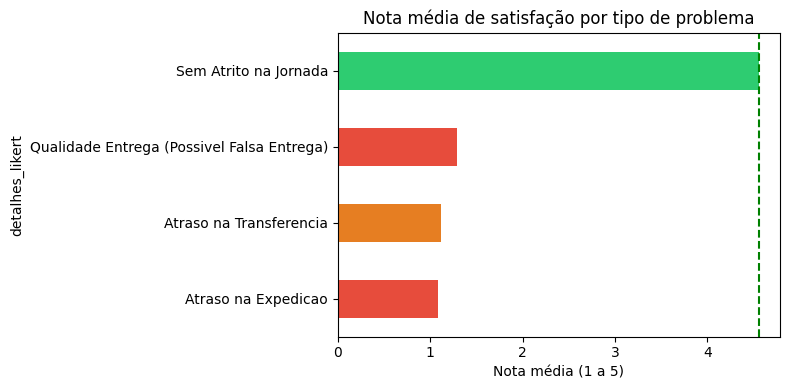

In [6]:
# Gráfico: nota de satisfação por tipo de problema
# Queremos visualizar o impacto de cada falha na nota

# Junta os problemas com a nota sem atrito para comparar
comparacao = impacto.copy()
comparacao['Sem Atrito na Jornada'] = nota_ok
comparacao = comparacao.sort_values()

# Cria o gráfico de barras horizontal
comparacao.plot(kind='barh', color=['#e74c3c', '#e67e22', '#e74c3c', '#2ecc71'], figsize=(8, 4))

plt.title('Nota média de satisfação por tipo de problema')
plt.xlabel('Nota média (1 a 5)')
plt.axvline(x=nota_ok, color='green', linestyle='--', linewidth=1.5, label='Referência sem problema')
plt.tight_layout()
plt.show()


In [7]:
# Quando o cliente avalia dependendo do tipo de problema?
# Antes da entrega = já está reclamando enquanto espera
# Depois da entrega = reclamou ao receber (ou não receber)

# Filtra fora os 'Sem Avaliacao'
momento = com_atrito[com_atrito['momento_likert'] != 'Sem Avaliacao']

# Cruza tipo de problema com momento da avaliação
# unstack() transforma os valores de momento_likert em colunas para facilitar a leitura
tabela_momento = momento.groupby(['detalhes_likert', 'momento_likert'])['volume_pedidos'].sum().unstack()

print(tabela_momento)


momento_likert                              Antes da Entrega  \
detalhes_likert                                                
Atraso na Expedicao                                    684.0   
Atraso na Transferencia                               4203.0   
Qualidade Entrega (Possivel Falsa Entrega)               NaN   

momento_likert                              Depois da Entrega  
detalhes_likert                                                
Atraso na Expedicao                                       NaN  
Atraso na Transferencia                                   NaN  
Qualidade Entrega (Possivel Falsa Entrega)             8911.0  


In [8]:
# Taxa de problemas por estado
# Volume absoluto pode enganar — estados grandes vendem mais
# O percentual mostra onde a operação é realmente pior

# Total de pedidos por estado (com e sem problema)
total_por_uf = df.groupby('uf_cliente')['volume_pedidos'].sum()

# Total de problemas por estado
problemas_por_uf = com_atrito.groupby('uf_cliente')['volume_pedidos'].sum()

# Calcula o percentual de problemas
taxa_problemas = (problemas_por_uf / total_por_uf * 100).round(1)

# Junta tudo numa tabela e ordena pelo maior percentual
tabela_uf = pd.DataFrame({
    'Total de Pedidos': total_por_uf,
    'Pedidos com Problema': problemas_por_uf,
    'Taxa de Problema (%)': taxa_problemas
}).sort_values('Taxa de Problema (%)', ascending=False).head(10)

print(tabela_uf)


            Total de Pedidos  Pedidos com Problema  Taxa de Problema (%)
uf_cliente                                                              
AL                       411                    96                  23.4
RR                        45                    10                  22.2
MA                       739                   158                  21.4
SE                       345                    72                  20.9
RJ                     12791                  2546                  19.9
PA                       974                   187                  19.2
CE                      1328                   249                  18.8
BA                      3358                   612                  18.2
PI                       493                    88                  17.8
PE                      1646                   269                  16.3


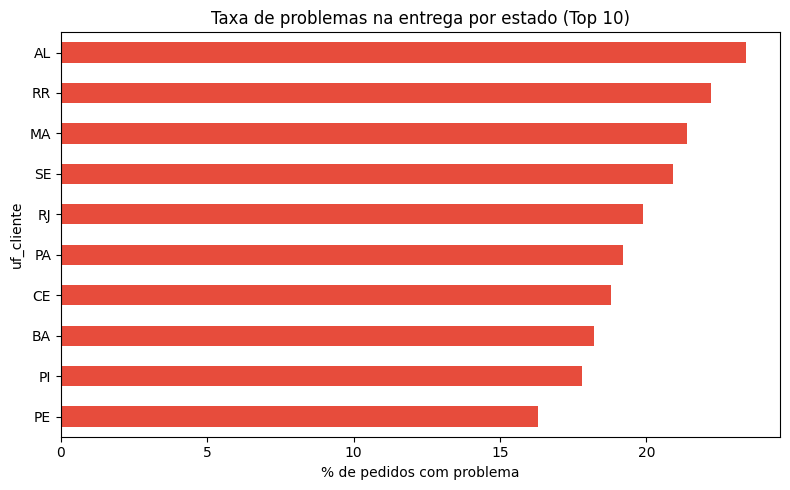

In [9]:
# Gráfico: taxa de problemas por estado (top 10)
# Mostra onde a operação logística é mais frágil no geral

tabela_uf['Taxa de Problema (%)'].plot(
    kind='barh',
    figsize=(8, 5),
    color='#e74c3c'
)

plt.title('Taxa de problemas na entrega por estado (Top 10)')
plt.xlabel('% de pedidos com problema')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [10]:
# Perfil dos estados: atraso vs falsa entrega
# Estados pequenos (AL, RR, MA) somem no ranking de falsa entrega
# porque seu problema principal é ATRASO, não falsa entrega
# Aqui provamos isso separando os dois tipos por estado

# Filtra cada tipo de problema separadamente
atraso = com_atrito[com_atrito['detalhes_likert'].isin(
    ['Atraso na Transferencia', 'Atraso na Expedicao']
)]
falsa = com_atrito[com_atrito['detalhes_likert'] == 'Qualidade Entrega (Possivel Falsa Entrega)']

# Total de pedidos por estado
total_por_uf = df.groupby('uf_cliente')['volume_pedidos'].sum()

# Taxa de atraso por estado
taxa_atraso = (atraso.groupby('uf_cliente')['volume_pedidos'].sum() / total_por_uf * 100).round(1)

# Taxa de falsa entrega por estado (só estados com +500 pedidos)
taxa_falsa = (falsa.groupby('uf_cliente')['volume_pedidos'].sum() / total_por_uf * 100).round(1)

# Monta tabela comparativa
perfil = pd.DataFrame({
    'Total Pedidos': total_por_uf,
    'Taxa Atraso (%)': taxa_atraso,
    'Taxa Falsa Entrega (%)': taxa_falsa
}).dropna().sort_values('Taxa Atraso (%)', ascending=False)

print('Perfil por estado — atraso vs falsa entrega:')
print(perfil.head(15).to_string())


Perfil por estado — atraso vs falsa entrega:
            Total Pedidos  Taxa Atraso (%)  Taxa Falsa Entrega (%)
uf_cliente                                                        
RR                     45             17.8                     4.4
AL                    411             15.6                     7.8
SE                    345             11.6                     9.3
MA                    739             11.4                    10.0
CE                   1328             11.1                     7.7
RJ                  12791              9.9                    10.1
PI                    493              9.3                     8.5
PA                    974              9.2                    10.0
BA                   3358              8.3                     9.9
PE                   1646              7.8                     8.5
PB                    531              7.7                     8.5
RN                    484              7.0                     7.0
MS               

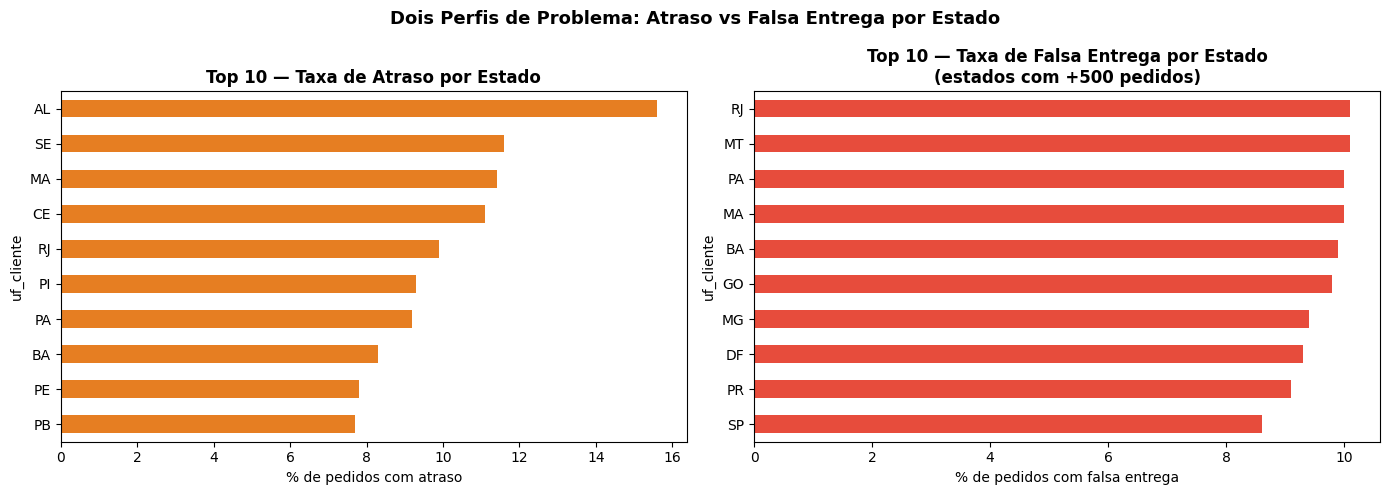


Conclusão: AL, MA e SE lideram em ATRASO.
RJ, MT e BA lideram em FALSA ENTREGA.
São problemas distintos que exigem soluções diferentes.


In [11]:
# Gráfico: comparação entre taxa de atraso e falsa entrega por estado
# Mostra que AL, RR e MA sofrem com atraso
# enquanto RJ, MT e BA sofrem com falsa entrega — problemas diferentes!

# Filtra estados com pelo menos 300 pedidos para evitar distorção
perfil_filtrado = perfil[perfil['Total Pedidos'] >= 300].copy()

# Seleciona os 10 com maior taxa de atraso
top_atraso = perfil_filtrado.sort_values('Taxa Atraso (%)', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dois Perfis de Problema: Atraso vs Falsa Entrega por Estado',
             fontsize=13, fontweight='bold')

# Gráfico 1: Estados com mais atraso
top_atraso['Taxa Atraso (%)'].sort_values().plot(
    kind='barh', ax=axes[0], color='#e67e22')
axes[0].set_title('Top 10 — Taxa de Atraso por Estado', fontweight='bold')
axes[0].set_xlabel('% de pedidos com atraso')

# Gráfico 2: Estados com mais falsa entrega (filtro 500 pedidos)
top_falsa = perfil_filtrado[perfil_filtrado['Total Pedidos'] >= 500].sort_values(
    'Taxa Falsa Entrega (%)', ascending=False).head(10)
top_falsa['Taxa Falsa Entrega (%)'].sort_values().plot(
    kind='barh', ax=axes[1], color='#e74c3c')
axes[1].set_title('Top 10 — Taxa de Falsa Entrega por Estado\n(estados com +500 pedidos)', fontweight='bold')
axes[1].set_xlabel('% de pedidos com falsa entrega')

plt.tight_layout()
plt.show()

print('\nConclusão: AL, MA e SE lideram em ATRASO.')
print('RJ, MT e BA lideram em FALSA ENTREGA.')
print('São problemas distintos que exigem soluções diferentes.')


In [12]:
# Provando que o problema é na ponta final da entrega
# Separamos os 3 tipos de problema para comparar
# quem é responsável por cada um

# Cria uma tabela com volume, nota e momento para cada problema
prova = com_atrito.groupby('detalhes_likert').agg(
    volume=('volume_pedidos', 'sum'),
    nota_media=('nota_media_satisfacao', 'mean'),
    momento_mais_comum=('momento_likert', lambda x: x.value_counts().index[0])
).round(2).sort_values('volume', ascending=False)

print(prova)


                                            volume  nota_media  \
detalhes_likert                                                  
Qualidade Entrega (Possivel Falsa Entrega)    8911        1.29   
Atraso na Transferencia                       4203        1.12   
Atraso na Expedicao                            684        1.09   

                                           momento_mais_comum  
detalhes_likert                                                
Qualidade Entrega (Possivel Falsa Entrega)  Depois da Entrega  
Atraso na Transferencia                      Antes da Entrega  
Atraso na Expedicao                          Antes da Entrega  


In [13]:
# Cruzando falsa entrega com performance de entrega
# Se o entregador marcou como entregue sem entregar,
# o sistema registra 'No Prazo' — isso é a prova

# Filtra só os casos de falsa entrega
falsa_entrega = df[df['detalhes_likert'] == 'Qualidade Entrega (Possivel Falsa Entrega)']

# Vê como o sistema classificou a performance desses pedidos
print('Como o sistema classificou os pedidos de falsa entrega:')
print(falsa_entrega['performance_entrega'].value_counts())

# Calcula o percentual
total_falsa = falsa_entrega['performance_entrega'].count()
print('\nEm percentual:')
print((falsa_entrega['performance_entrega'].value_counts() / total_falsa * 100).round(1))


Como o sistema classificou os pedidos de falsa entrega:
performance_entrega
No Prazo    8289
Atrasado     527
Name: count, dtype: int64

Em percentual:
performance_entrega
No Prazo    94.0
Atrasado     6.0
Name: count, dtype: float64


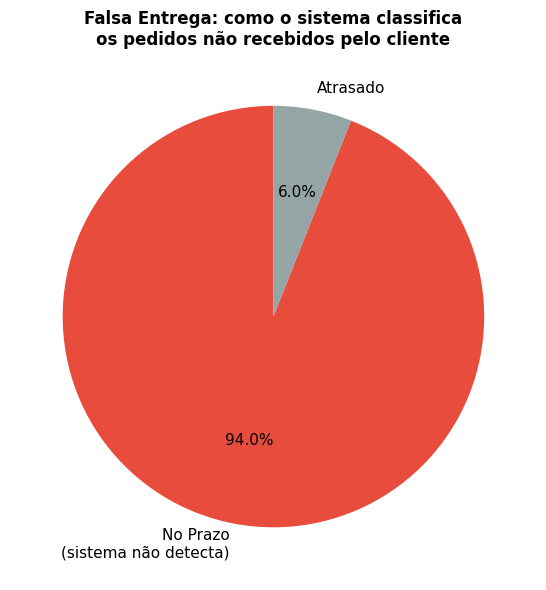

In [14]:
# Gráfico: a prova da falsa entrega
# Mostra que 94% dos casos aparecem como 'No Prazo'
# no sistema — invisível para o monitoramento padrão

labels = ['No Prazo\n(sistema não detecta)', 'Atrasado']
valores = [94.0, 6.0]
cores = ['#e74c3c', '#95a5a6']

plt.figure(figsize=(6, 6))
plt.pie(valores, labels=labels, autopct='%1.1f%%', colors=cores,
        startangle=90, textprops={'fontsize': 11})

plt.title('Falsa Entrega: como o sistema classifica\nos pedidos não recebidos pelo cliente',
          fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


In [15]:
# Falsa entrega por estado
# Filtra estados com pelo menos 500 pedidos
# para evitar distorção em estados com pouco volume

# Total de pedidos por estado
total_por_estado = df.groupby('uf_cliente')['volume_pedidos'].sum()

# Falsa entrega por estado
falsa_por_estado = falsa_entrega.groupby('uf_cliente')['volume_pedidos'].sum()

# Monta tabela
falsa_tabela = pd.DataFrame({
    'Total Pedidos': total_por_estado,
    'Falsa Entrega': falsa_por_estado
}).dropna()

# Filtra só estados com pelo menos 500 pedidos
falsa_tabela = falsa_tabela[falsa_tabela['Total Pedidos'] >= 500]

# Calcula taxa
falsa_tabela['Taxa (%)'] = (falsa_tabela['Falsa Entrega'] / falsa_tabela['Total Pedidos'] * 100).round(1)

# Ordena e pega top 10
falsa_por_uf_sorted = falsa_tabela.sort_values('Taxa (%)', ascending=True).tail(10).reset_index()
falsa_por_uf_sorted.columns = ['Estado', 'Total Pedidos', 'Falsa Entrega', 'Taxa (%)']

print(falsa_por_uf_sorted.sort_values('Taxa (%)', ascending=False).to_string(index=False))


Estado  Total Pedidos  Falsa Entrega  Taxa (%)
    RJ          12791           1286      10.1
    MT            908             92      10.1
    MA            739             74      10.0
    PA            974             97      10.0
    BA           3358            334       9.9
    GO           2015            197       9.8
    MG          11594           1092       9.4
    DF           2128            198       9.3
    PR           5018            456       9.1
    SP          41470           3574       8.6


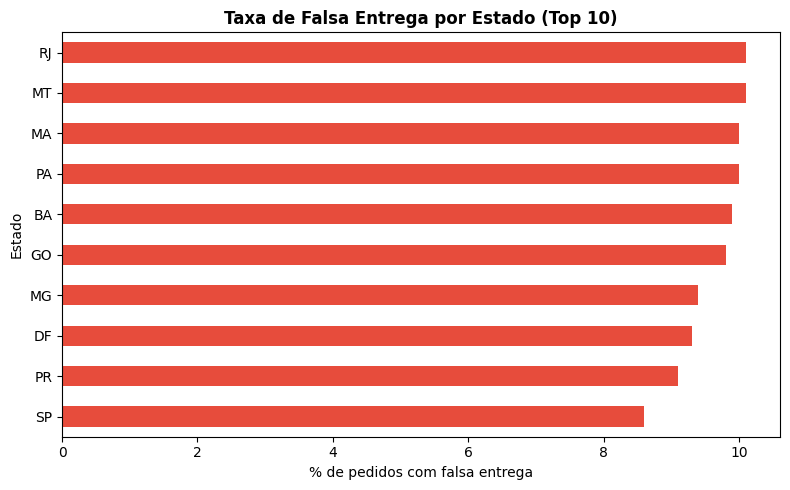

In [16]:
# Gráfico: taxa de falsa entrega por estado (top 10)
# Filtrado para estados com pelo menos 500 pedidos

falsa_por_uf_sorted.sort_values('Taxa (%)', ascending=False).plot(
    x='Estado', y='Taxa (%)', kind='barh',
    figsize=(8, 5), color='#e74c3c', legend=False
)

plt.title('Taxa de Falsa Entrega por Estado (Top 10)', fontsize=12, fontweight='bold')
plt.xlabel('% de pedidos com falsa entrega')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


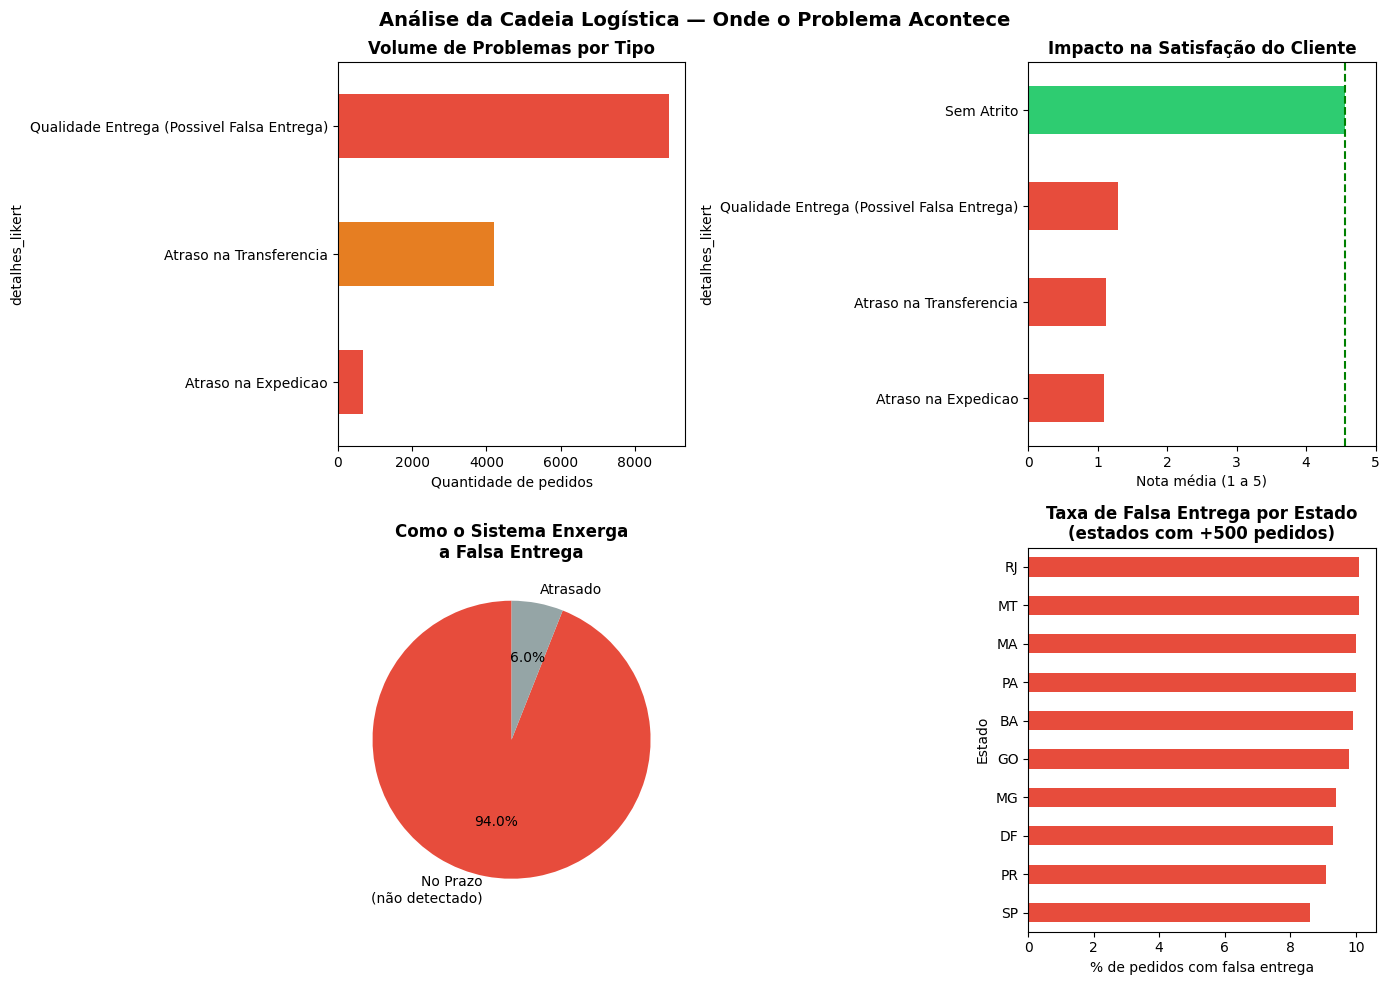

In [17]:
# Painel final: visão completa da análise
# 4 gráficos numa tela só contando a história completa

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análise da Cadeia Logística — Onde o Problema Acontece',
             fontsize=14, fontweight='bold')

# --- Gráfico 1: Volume por tipo de problema ---
ax1 = axes[0, 0]
prova['volume'].sort_values().plot(kind='barh', ax=ax1, color=['#e74c3c', '#e67e22', '#e74c3c'])
ax1.set_title('Volume de Problemas por Tipo', fontweight='bold')
ax1.set_xlabel('Quantidade de pedidos')

# --- Gráfico 2: Impacto na satisfação ---
ax2 = axes[0, 1]
notas = prova['nota_media'].copy()
notas['Sem Atrito'] = nota_ok
notas = notas.sort_values()
cores2 = ['#e74c3c'] * (len(notas) - 1) + ['#2ecc71']
notas.plot(kind='barh', ax=ax2, color=cores2)
ax2.set_title('Impacto na Satisfação do Cliente', fontweight='bold')
ax2.set_xlabel('Nota média (1 a 5)')
ax2.axvline(x=nota_ok, color='green', linestyle='--', linewidth=1.5)
ax2.set_xlim(0, 5)

# --- Gráfico 3: Falsa entrega invisível no sistema ---
ax3 = axes[1, 0]
labels = ['No Prazo\n(não detectado)', 'Atrasado']
valores = [94.0, 6.0]
ax3.pie(valores, labels=labels, autopct='%1.1f%%',
        colors=['#e74c3c', '#95a5a6'], startangle=90)
ax3.set_title('Como o Sistema Enxerga\na Falsa Entrega', fontweight='bold')

# --- Gráfico 4: Taxa de falsa entrega por estado ---
ax4 = axes[1, 1]
falsa_por_uf_sorted.sort_values('Taxa (%)', ascending=False).plot(
    x='Estado', y='Taxa (%)', kind='barh', ax=ax4, color='#e74c3c', legend=False)
ax4.set_title('Taxa de Falsa Entrega por Estado\n(estados com +500 pedidos)', fontweight='bold')
ax4.set_xlabel('% de pedidos com falsa entrega')
ax4.invert_yaxis()

plt.tight_layout()
plt.show()


# Análise da Cadeia Logística — E-Commerce

## O que os dados provaram

- **13.9%** dos pedidos têm algum problema na entrega
- A **falsa entrega** é o maior problema: 8.911 casos (64% do total com atrito)
- Qualquer falha derruba a nota média de **4.56 para ~1.2**
- **94%** das falsas entregas aparecem como *"No Prazo"* no sistema — o problema é **invisível** para o monitoramento padrão
- **Dois perfis distintos de problema por estado:**
  - AL, MA e SE lideram em **taxa de atraso** — problema na transportadora/expedição
  - RJ, MT e BA lideram em **taxa de falsa entrega** — problema no entregador

---

## Onde a cadeia quebra

| Tipo de Problema | Volume | Nota Média | Momento da Reclamação | Responsável |
|---|---|---|---|---|
| Falsa Entrega | 8.911 | 1.29 | Depois da entrega | Entregador |
| Atraso na Transferência | 4.203 | 1.12 | Antes da entrega | Transportadora |
| Atraso na Expedição | 684 | 1.09 | Antes da entrega | Vendedor |
| Sem Problema | 78.161 | 4.56 | — | — |

---

## Recomendações para a empresa

### 1. Confirmação de entrega pelo cliente
Implementar notificação automática ao cliente no momento em que o sistema registrar a entrega. O cliente confirma com um clique — se não confirmar em X horas, uma ocorrência é aberta automaticamente.

### 2. Monitoramento por entregador
Cruzar os dados de falsa entrega com o código do entregador para identificar padrões. Entregadores com alta taxa devem ser investigados e desligados se necessário.

### 3. Foco diferenciado por estado
- **RJ, MT e BA** → fiscalização reforçada na última milha (falsa entrega)
- **AL, MA e SE** → revisão de transportadoras e prazos de expedição (atraso)

### 4. Alerta proativo ao cliente
Nos casos de atraso na transferência, o cliente reclama **antes** de receber. Comunicar o atraso proativamente reduz a insatisfação antes que ela vire avaliação negativa.

### 5. Revisão do indicador de performance
O KPI atual (*No Prazo / Atrasado*) não captura falsa entrega. É necessário um novo indicador que cruze performance de entrega com confirmação do cliente.
